In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!unzip -q /content/drive/MyDrive/Luna16.zip

In [6]:
!pip install -q tensorflow scikit-learn pandas numpy matplotlib joblib streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 104.9 MB/s eta 0:00:00


In [7]:
# Import all required libraries
import os
import glob
import json
import random
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import joblib

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUTPUT_DIR = "/content/luna16_milestone4_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
# Dataset paths
ANNOTATIONS_CSV = "/content/annotations.csv"
CANDIDATES_CSV = "/content/candidates_V2/candidates_V2.csv"
LUNA_IMG_DIR = "/content/seg-lungs-LUNA16/seg-lungs-LUNA16"

assert os.path.exists(ANNOTATIONS_CSV), "annotations.csv not found"
assert os.path.exists(CANDIDATES_CSV), "candidates_V2.csv not found"
assert os.path.exists(LUNA_IMG_DIR), "seg-lungs-LUNA16 folder not found"

annotations = pd.read_csv(ANNOTATIONS_CSV)
candidates = pd.read_csv(CANDIDATES_CSV)

In [9]:
print("annotations shape:", annotations.shape)
print("candidates shape:", candidates.shape)
print("positive candidates:", int(candidates["class"].sum()))
print("negative candidates:", int((candidates["class"] == 0).sum()))
print("scan files:", len(glob.glob(os.path.join(LUNA_IMG_DIR, "*.mhd"))))

annotations shape: (1186, 5)
candidates shape: (754975, 5)
positive candidates: 1557
negative candidates: 753418
scan files: 888


In [10]:
# Balanced candidate dataset
positive_df = candidates[candidates["class"].eq(1)].copy()
negative_df = candidates[candidates["class"].eq(0)].sample(n=len(positive_df), random_state=SEED).copy()

model_df = pd.concat([positive_df, negative_df], ignore_index=True)
model_df = model_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

model_df["x_abs"] = model_df["coordX"].abs()
model_df["y_abs"] = model_df["coordY"].abs()
model_df["z_abs"] = model_df["coordZ"].abs()
model_df["xy_distance"] = np.sqrt(model_df["coordX"]**2 + model_df["coordY"]**2)
model_df["xz_distance"] = np.sqrt(model_df["coordX"]**2 + model_df["coordZ"]**2)
model_df["yz_distance"] = np.sqrt(model_df["coordY"]**2 + model_df["coordZ"]**2)
model_df["xyz_distance"] = np.sqrt(model_df["coordX"]**2 + model_df["coordY"]**2 + model_df["coordZ"]**2)
model_df["x_y"] = model_df["coordX"] * model_df["coordY"]
model_df["x_z"] = model_df["coordX"] * model_df["coordZ"]
model_df["y_z"] = model_df["coordY"] * model_df["coordZ"]
model_df["x_sq"] = model_df["coordX"]**2
model_df["y_sq"] = model_df["coordY"]**2
model_df["z_sq"] = model_df["coordZ"]**2
model_df["x_sign"] = np.sign(model_df["coordX"])
model_df["y_sign"] = np.sign(model_df["coordY"])
model_df["z_sign"] = np.sign(model_df["coordZ"])

print("model rows:", len(model_df))
print(model_df["class"].value_counts())

model_df.to_csv(os.path.join(OUTPUT_DIR, "milestone4_engineered_candidates.csv"), index=False)

model rows: 3114
class
1    1557
0    1557
Name: count, dtype: int64


In [11]:
# Feature matrix
feature_cols = [
    "coordX", "coordY", "coordZ",
    "x_abs", "y_abs", "z_abs",
    "xy_distance", "xz_distance", "yz_distance", "xyz_distance",
    "x_y", "x_z", "y_z",
    "x_sq", "y_sq", "z_sq",
    "x_sign", "y_sign", "z_sign"
]

X_raw = model_df[feature_cols].astype("float32")
y = model_df["class"].astype("int32").to_numpy()
groups = model_df["seriesuid"].astype(str).to_numpy()

In [12]:
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_poly = poly.fit_transform(X_raw).astype("float32")

In [13]:
splitter_one = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(splitter_one.split(X_poly, y, groups))

In [14]:
splitter_two = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_rel_idx, test_rel_idx = next(splitter_two.split(X_poly[temp_idx], y[temp_idx], groups[temp_idx]))

In [15]:
val_idx = temp_idx[val_rel_idx]
test_idx = temp_idx[test_rel_idx]

In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_poly[train_idx]).astype("float32")
X_val = scaler.transform(X_poly[val_idx]).astype("float32")
X_test = scaler.transform(X_poly[test_idx]).astype("float32")

In [17]:
y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]

In [18]:
print("features:", X_train.shape[1])
print("train:", X_train.shape, "positives:", int(y_train.sum()))
print("validation:", X_val.shape, "positives:", int(y_val.sum()))
print("test:", X_test.shape, "positives:", int(y_test.sum()))

joblib.dump(poly, os.path.join(OUTPUT_DIR, "polynomial_features.joblib"))
joblib.dump(scaler, os.path.join(OUTPUT_DIR, "standard_scaler.joblib"))
pd.Series(feature_cols).to_csv(os.path.join(OUTPUT_DIR, "feature_columns.csv"), index=False, header=False)

features: 209
train: (2141, 209) positives: 1068
validation: (497, 209) positives: 234
test: (476, 209) positives: 255


In [19]:
# Dense neural network
tf.keras.backend.clear_session()

inputs = tf.keras.Input(shape=(X_train.shape[1],), name="candidate_features")
x = tf.keras.layers.BatchNormalization()(inputs)
x = tf.keras.layers.Dense(512, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.0005))(x)
x = tf.keras.layers.Dropout(0.35)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.0005))(x)
x = tf.keras.layers.Dropout(0.30)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.0005))(x)
x = tf.keras.layers.Dropout(0.25)(x)
x = tf.keras.layers.Dense(64, activation="relu")(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="nodule_probability")(x)

In [20]:
model = tf.keras.Model(inputs=inputs, outputs=outputs, name="Milestone4_Balanced_DenseNet")

In [21]:
loss_fn = tf.keras.losses.BinaryFocalCrossentropy(
    apply_class_balancing=True,
    alpha=0.50,
    gamma=2.0
)

In [22]:
# Compile Model
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.0001),
    loss=loss_fn,
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [23]:
# Model Summary
model.summary()

Model: "Milestone4_Balanced_DenseNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ candidate_features (InputLayer) │ (None, 209)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 209)            │           836 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       107,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ nodule_probability (Dense)      │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 283,973 (1.08 MB)

 Trainable params: 282,019 (1.08 MB)

 Non-trainable params: 1,954 (7.63 KB)

In [24]:
# Training
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", patience=4, factor=0.5, min_lr=1e-5),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(OUTPUT_DIR, "best_milestone4_model.keras"),
        monitor="val_auc",
        mode="max",
        save_best_only=True
    )
]

In [25]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

pd.DataFrame(history.history).to_csv(os.path.join(OUTPUT_DIR, "training_history.csv"), index=False)

Epoch 1/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 32s 405ms/step - accuracy: 0.5297 - auc: 0.5412 - loss: 0.5319 - precision: 0.5270 - recall: 0.5581 - val_accuracy: 0.5372 - val_auc: 0.5824 - val_loss: 0.4817 - val_precision: 0.5185 - val_recall: 0.2393 - learning_rate: 0.0010
Epoch 2/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5395 - auc: 0.5580 - loss: 0.4833 - precision: 0.5400 - recall: 0.5178 - val_accuracy: 0.5855 - val_auc: 0.6360 - val_loss: 0.4591 - val_precision: 0.5921 - val_recall: 0.3846 - learning_rate: 0.0010
Epoch 3/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5558 - auc: 0.5848 - loss: 0.4566 - precision: 0.5557 - recall: 0.5468 - val_accuracy: 0.5875 - val_auc: 0.6072 - val_loss: 0.4411 - val_precision: 0.5801 - val_recall: 0.4487 - learning_rate: 0.0010
Epoch 4/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5530 - auc: 0.5742 - loss: 0.4361 - precision: 0.5529 - recall: 0.5431 - val_accuracy: 0.5634 - val_auc: 0.6147 - val_loss: 0.4198 - val_prec

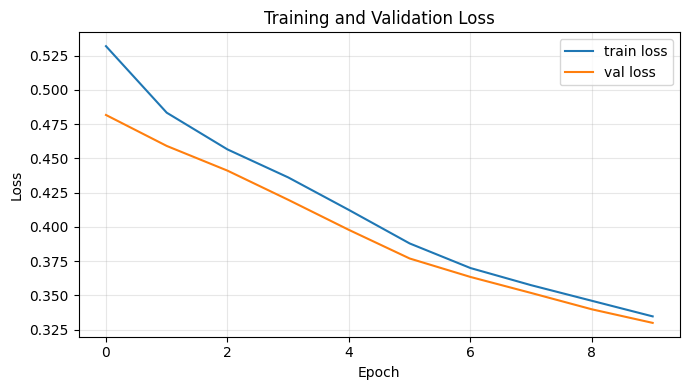

In [26]:
# Loss Curve
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(7, 4))
plt.plot(history_df["loss"], label="train loss")
plt.plot(history_df["val_loss"], label="val loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "loss_curve.png"), dpi=150)
plt.show()

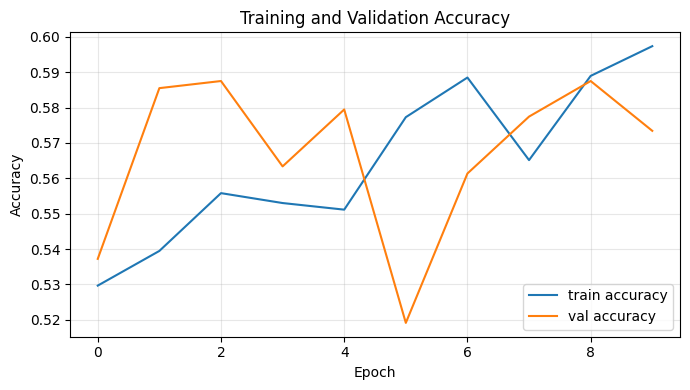

In [27]:
# Accuracy Curve
plt.figure(figsize=(7, 4))
plt.plot(history_df["accuracy"], label="train accuracy")
plt.plot(history_df["val_accuracy"], label="val accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "accuracy_curve.png"), dpi=150)
plt.show()

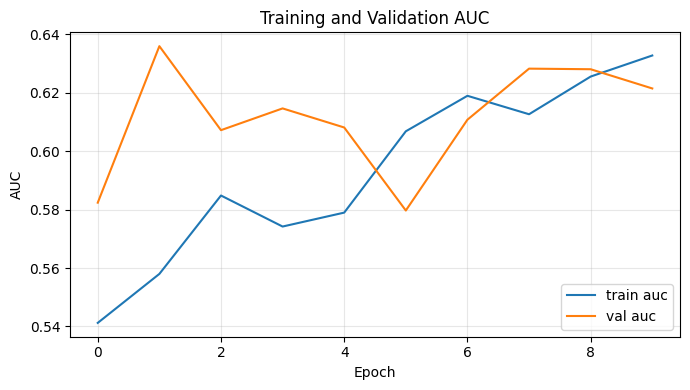

In [28]:
# ROC-AUC curve
plt.figure(figsize=(7, 4))
plt.plot(history_df["auc"], label="train auc")
plt.plot(history_df["val_auc"], label="val auc")
plt.title("Training and Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "auc_curve.png"), dpi=150)
plt.show()

In [29]:
# Threshold tuning
val_prob = model.predict(X_val, verbose=0).ravel()
thresholds = np.round(np.arange(0.05, 0.96, 0.01), 2)

pred_matrix = (val_prob[:, None] >= thresholds[None, :]).astype("int32")
truth_matrix = y_val[:, None]

tp = ((pred_matrix == 1) & (truth_matrix == 1)).sum(axis=0)
tn = ((pred_matrix == 0) & (truth_matrix == 0)).sum(axis=0)
fp = ((pred_matrix == 1) & (truth_matrix == 0)).sum(axis=0)
fn = ((pred_matrix == 0) & (truth_matrix == 1)).sum(axis=0)

precision_values = tp / np.maximum(tp + fp, 1)
recall_values = tp / np.maximum(tp + fn, 1)
specificity_values = tn / np.maximum(tn + fp, 1)
accuracy_values = (tp + tn) / np.maximum(tp + tn + fp + fn, 1)
balanced_values = (recall_values + specificity_values) / 2
f1_values = 2 * precision_values * recall_values / np.maximum(precision_values + recall_values, 1e-8)

threshold_table = pd.DataFrame({
    "threshold": thresholds,
    "accuracy": accuracy_values,
    "balanced_accuracy": balanced_values,
    "precision": precision_values,
    "recall": recall_values,
    "specificity": specificity_values,
    "f1_score": f1_values
})

In [30]:
best_f1_threshold = float(threshold_table.loc[threshold_table["f1_score"].idxmax(), "threshold"])
best_balanced_threshold = float(threshold_table.loc[threshold_table["balanced_accuracy"].idxmax(), "threshold"])

threshold_table.to_csv(os.path.join(OUTPUT_DIR, "validation_threshold_table.csv"), index=False)

In [31]:
print("best f1 threshold:", best_f1_threshold)
print("best balanced threshold:", best_balanced_threshold)
print(threshold_table.sort_values("f1_score", ascending=False).head(10).round(4))

best f1 threshold: 0.47
best balanced threshold: 0.48
    threshold  accuracy  balanced_accuracy  precision  recall  specificity  \
42       0.47    0.5895             0.6046     0.5401  0.8632       0.3460   
40       0.45    0.5412             0.5632     0.5069  0.9402       0.1863   
39       0.44    0.5292             0.5530     0.5000  0.9615       0.1445   
38       0.43    0.5171             0.5421     0.4935  0.9701       0.1141   
37       0.42    0.5091             0.5345     0.4892  0.9701       0.0989   
41       0.46    0.5433             0.5630     0.5084  0.9017       0.2243   
43       0.48    0.6197             0.6268     0.5738  0.7479       0.5057   
36       0.41    0.4970             0.5235     0.4831  0.9786       0.0684   
35       0.40    0.4930             0.5200     0.4812  0.9829       0.0570   
34       0.39    0.4849             0.5124     0.4772  0.9829       0.0418   

    f1_score  
42    0.6645  
40    0.6587  
39    0.6579  
38    0.6542  
37    0.6504

In [32]:
# Final test evaluation
test_prob = model.predict(X_test, verbose=0).ravel()
test_pred = (test_prob >= best_f1_threshold).astype("int32")

final_metrics = pd.DataFrame({
    "metric": [
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "threshold"
    ],
    "value": [
        accuracy_score(y_test, test_pred),
        balanced_accuracy_score(y_test, test_pred),
        precision_score(y_test, test_pred, zero_division=0),
        recall_score(y_test, test_pred, zero_division=0),
        f1_score(y_test, test_pred, zero_division=0),
        roc_auc_score(y_test, test_prob),
        best_f1_threshold
    ]
})

In [33]:
final_metrics.to_csv(os.path.join(OUTPUT_DIR, "final_test_metrics.csv"), index=False)
print(final_metrics.round(4).to_string(index=False))

           metric  value
         accuracy 0.5840
balanced_accuracy 0.5671
        precision 0.5807
           recall 0.8039
         f1_score 0.6743
          roc_auc 0.6023
        threshold 0.4700


In [34]:
cm = confusion_matrix(y_test, test_pred)
cm_df = pd.DataFrame(cm, index=["Actual Non-Nodule", "Actual Nodule"], columns=["Predicted Non-Nodule", "Predicted Nodule"])
cm_df.to_csv(os.path.join(OUTPUT_DIR, "confusion_matrix.csv"))
cm_df

,Predicted Non-Nodule,Predicted Nodule
Actual Non-Nodule,73,148
Actual Nodule,50,205


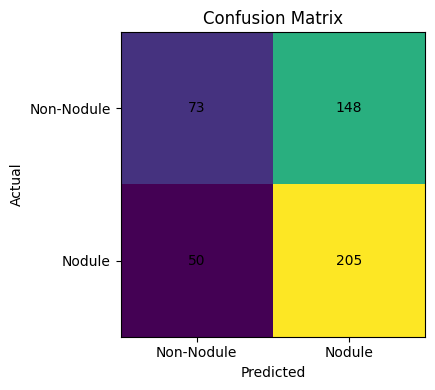

In [35]:
# Evaluation plots
plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.xticks([0, 1], ["Non-Nodule", "Nodule"])
plt.yticks([0, 1], ["Non-Nodule", "Nodule"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.text(0, 0, cm[0, 0], ha="center", va="center")
plt.text(1, 0, cm[0, 1], ha="center", va="center")
plt.text(0, 1, cm[1, 0], ha="center", va="center")
plt.text(1, 1, cm[1, 1], ha="center", va="center")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

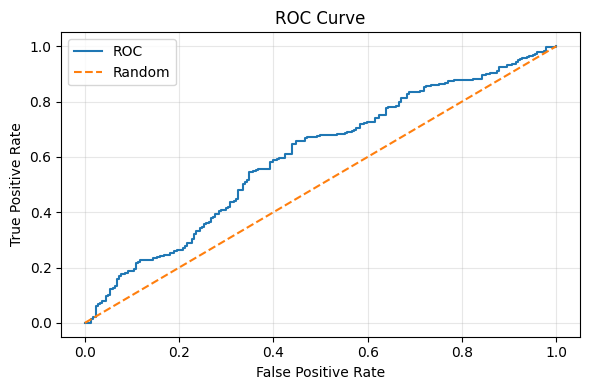

In [36]:
fpr, tpr, roc_thresholds = roc_curve(y_test, test_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label="ROC")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "roc_curve.png"), dpi=150)
plt.show()

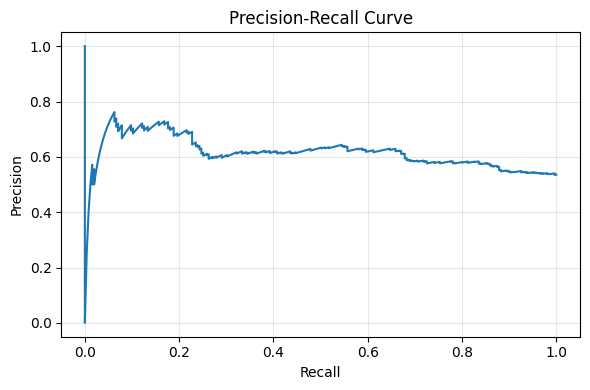

In [37]:
pr_precision, pr_recall, pr_thresholds = precision_recall_curve(y_test, test_prob)
plt.figure(figsize=(6, 4))
plt.plot(pr_recall, pr_precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "precision_recall_curve.png"), dpi=150)
plt.show()

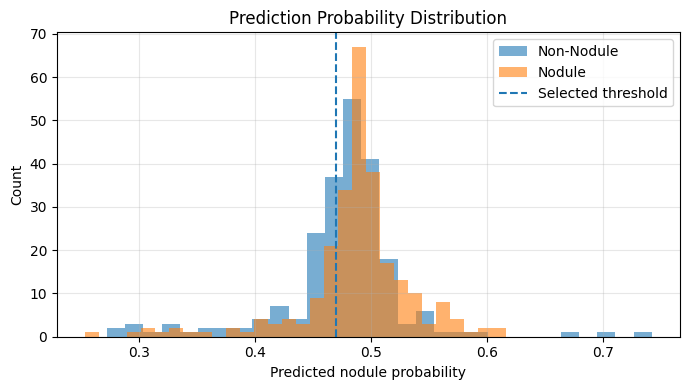

In [38]:
plt.figure(figsize=(7, 4))
plt.hist(test_prob[y_test == 0], bins=30, alpha=0.6, label="Non-Nodule")
plt.hist(test_prob[y_test == 1], bins=30, alpha=0.6, label="Nodule")
plt.axvline(best_f1_threshold, linestyle="--", label="Selected threshold")
plt.title("Prediction Probability Distribution")
plt.xlabel("Predicted nodule probability")
plt.ylabel("Count")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "probability_distribution.png"), dpi=150)
plt.show()

In [39]:
# Save prediction samples
test_rows = model_df.iloc[test_idx].copy()
test_rows["new_probability"] = test_prob
test_rows["new_prediction"] = test_pred

cols_to_save = ["seriesuid", "coordX", "coordY", "coordZ", "class", "new_probability", "new_prediction"]
test_rows[cols_to_save].to_csv(os.path.join(OUTPUT_DIR, "test_predictions.csv"), index=False)

print(test_rows[["coordX", "coordY", "coordZ", "class", "new_probability", "new_prediction"]].head(12).round(4).to_string(index=False))

  coordX    coordY    coordZ  class  new_probability  new_prediction
 45.4406  -33.9706 -141.5571      1           0.4979               1
-58.8383  181.0842 1694.5963      0           0.3711               0
-37.2909 -118.2139  841.4883      0           0.3259               0
 53.1900   35.1700  -75.4100      0           0.4798               1
 64.4547   43.7935 -236.0111      1           0.4829               1
 59.0400 -109.2300 -116.5600      0           0.4818               1
 76.7200   51.6300 -234.5800      0           0.5001               1
-72.0300  -13.1100 -169.6600      0           0.4719               1
 76.1494   72.0105  -96.6500      1           0.4936               1
 85.2200 -206.4300  167.1900      1           0.4840               1
-71.0172   20.3316  -23.5627      1           0.4944               1
-93.5500  -49.5700 -148.1200      1           0.4889               1


In [40]:
# Save model files
model.save(os.path.join(OUTPUT_DIR, "milestone4_candidate_densenet.keras"))

config = {
    "model_name": "Milestone4_Balanced_DenseNet",
    "dataset": "LUNA16 candidates_V2.csv",
    "input_features": feature_cols,
    "polynomial_features": True,
    "threshold": best_f1_threshold,
    "target_classes": {
        "0": "Non-Nodule",
        "1": "Nodule"
    }
}

with open(os.path.join(OUTPUT_DIR, "model_config.json"), "w") as f:
    json.dump(config, f, indent=4)

print("model saved")
print("output folder:", OUTPUT_DIR)

model saved
output folder: /content/luna16_milestone4_output


## Deployment Section: Streamlit Application with Ngrok



In [41]:
# Deployment artifact check
model_artifact = os.path.exists(os.path.join(OUTPUT_DIR, "milestone4_candidate_densenet.keras"))
poly_artifact = os.path.exists(os.path.join(OUTPUT_DIR, "polynomial_features.joblib"))
scaler_artifact = os.path.exists(os.path.join(OUTPUT_DIR, "standard_scaler.joblib"))
config_artifact = os.path.exists(os.path.join(OUTPUT_DIR, "model_config.json"))
metrics_artifact = os.path.exists(os.path.join(OUTPUT_DIR, "final_test_metrics.csv"))
predictions_artifact = os.path.exists(os.path.join(OUTPUT_DIR, "test_predictions.csv"))

deployment_status = pd.DataFrame({
    "artifact": [
        "milestone4_candidate_densenet.keras",
        "polynomial_features.joblib",
        "standard_scaler.joblib",
        "model_config.json",
        "final_test_metrics.csv",
        "test_predictions.csv"
    ],
    "available": [
        model_artifact,
        poly_artifact,
        scaler_artifact,
        config_artifact,
        metrics_artifact,
        predictions_artifact
    ]
})

print(deployment_status.to_string(index=False))

if deployment_status["available"].all():
    print("\nAll required deployment artifacts are available.")
else:
    print("\nRun the previous training, evaluation, and model-saving cells before deployment.")


                           artifact  available
milestone4_candidate_densenet.keras       True
         polynomial_features.joblib       True
             standard_scaler.joblib       True
                  model_config.json       True
             final_test_metrics.csv       True
               test_predictions.csv       True

All required deployment artifacts are available.


### Streamlit App Code


In [42]:
# Create the Streamlit application file
app_code = r"""# Streamlit app for LUNA16 Milestone 4 deployment
# This app uses the saved model, scaler, polynomial transformer, and config files.

import os
import json
import numpy as np
import pandas as pd
import streamlit as st
import tensorflow as tf
import joblib

# Locate saved deployment artifacts
ARTIFACT_DIR = os.path.dirname(os.path.abspath(__file__))
MODEL_PATH = os.path.join(ARTIFACT_DIR, "milestone4_candidate_densenet.keras")
BEST_MODEL_PATH = os.path.join(ARTIFACT_DIR, "best_milestone4_model.keras")
POLY_PATH = os.path.join(ARTIFACT_DIR, "polynomial_features.joblib")
SCALER_PATH = os.path.join(ARTIFACT_DIR, "standard_scaler.joblib")
CONFIG_PATH = os.path.join(ARTIFACT_DIR, "model_config.json")
METRICS_PATH = os.path.join(ARTIFACT_DIR, "final_test_metrics.csv")
PREDICTIONS_PATH = os.path.join(ARTIFACT_DIR, "test_predictions.csv")

# Page configuration
st.set_page_config(
    page_title="LUNA16 Nodule Prediction",
    page_icon="🫁",
    layout="wide"
)

st.title("LUNA16 Lung Nodule Candidate Prediction")
st.write(
    "This deployment page uses the trained Milestone 4 Dense Neural Network model "
    "to predict whether a CT candidate coordinate is a **Nodule** or **Non-Nodule**."
)

# Load artifacts
model_file = MODEL_PATH if os.path.exists(MODEL_PATH) else BEST_MODEL_PATH

if not os.path.exists(model_file):
    st.error("Saved Keras model file was not found in the deployment artifact folder.")
    st.stop()

if not os.path.exists(POLY_PATH):
    st.error("polynomial_features.joblib was not found in the deployment artifact folder.")
    st.stop()

if not os.path.exists(SCALER_PATH):
    st.error("standard_scaler.joblib was not found in the deployment artifact folder.")
    st.stop()

if not os.path.exists(CONFIG_PATH):
    st.error("model_config.json was not found in the deployment artifact folder.")
    st.stop()

model = tf.keras.models.load_model(model_file, compile=False)
poly = joblib.load(POLY_PATH)
scaler = joblib.load(SCALER_PATH)

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

threshold = float(config.get("threshold", 0.50))
feature_cols = config.get(
    "input_features",
    [
        "coordX", "coordY", "coordZ",
        "x_abs", "y_abs", "z_abs",
        "xy_distance", "xz_distance", "yz_distance", "xyz_distance",
        "x_y", "x_z", "y_z",
        "x_sq", "y_sq", "z_sq",
        "x_sign", "y_sign", "z_sign"
    ]
)

# Sidebar input section
st.sidebar.header("Candidate Coordinate Input")
coord_x = st.sidebar.number_input("coordX", value=0.0, step=1.0, format="%.4f")
coord_y = st.sidebar.number_input("coordY", value=0.0, step=1.0, format="%.4f")
coord_z = st.sidebar.number_input("coordZ", value=0.0, step=1.0, format="%.4f")

predict_button = st.sidebar.button("Predict Candidate")

# Show saved test metrics if available
st.subheader("Saved Model Performance")
if os.path.exists(METRICS_PATH):
    metrics_df = pd.read_csv(METRICS_PATH)
    metrics_display = metrics_df.copy()
    metrics_display["value"] = metrics_display["value"].astype(float).round(4)
    st.dataframe(metrics_display, use_container_width=True)
else:
    st.info("final_test_metrics.csv is not available yet. Run the training and evaluation cells first.")

# Build input features from the three candidate coordinates
input_df = pd.DataFrame({
    "coordX": [coord_x],
    "coordY": [coord_y],
    "coordZ": [coord_z]
})

input_df["x_abs"] = input_df["coordX"].abs()
input_df["y_abs"] = input_df["coordY"].abs()
input_df["z_abs"] = input_df["coordZ"].abs()
input_df["xy_distance"] = np.sqrt(input_df["coordX"]**2 + input_df["coordY"]**2)
input_df["xz_distance"] = np.sqrt(input_df["coordX"]**2 + input_df["coordZ"]**2)
input_df["yz_distance"] = np.sqrt(input_df["coordY"]**2 + input_df["coordZ"]**2)
input_df["xyz_distance"] = np.sqrt(input_df["coordX"]**2 + input_df["coordY"]**2 + input_df["coordZ"]**2)
input_df["x_y"] = input_df["coordX"] * input_df["coordY"]
input_df["x_z"] = input_df["coordX"] * input_df["coordZ"]
input_df["y_z"] = input_df["coordY"] * input_df["coordZ"]
input_df["x_sq"] = input_df["coordX"]**2
input_df["y_sq"] = input_df["coordY"]**2
input_df["z_sq"] = input_df["coordZ"]**2
input_df["x_sign"] = np.sign(input_df["coordX"])
input_df["y_sign"] = np.sign(input_df["coordY"])
input_df["z_sign"] = np.sign(input_df["coordZ"])

# Apply the same preprocessing pipeline used during model training
input_raw = input_df[feature_cols].astype("float32")
input_poly = poly.transform(input_raw).astype("float32")
input_scaled = scaler.transform(input_poly).astype("float32")

# Prediction panel
st.subheader("Prediction Result")
if predict_button:
    probability = float(model.predict(input_scaled, verbose=0).ravel()[0])
    prediction = int(probability >= threshold)
    class_labels = config.get("target_classes", {"0": "Non-Nodule", "1": "Nodule"})
    prediction_label = class_labels.get(str(prediction), str(prediction))

    left_col, right_col, third_col = st.columns(3)
    left_col.metric("Predicted Class", prediction_label)
    right_col.metric("Nodule Probability", f"{probability:.4f}")
    third_col.metric("Decision Threshold", f"{threshold:.4f}")

    if prediction == 1:
        st.warning("The model classified this candidate as a possible lung nodule.")
    else:
        st.success("The model classified this candidate as non-nodule.")

st.subheader("Engineered Input Features")
st.dataframe(input_df.round(4), use_container_width=True)

# Show saved sample predictions for reference
st.subheader("Saved Test Prediction Samples")
if os.path.exists(PREDICTIONS_PATH):
    sample_predictions = pd.read_csv(PREDICTIONS_PATH).head(20)
    st.dataframe(sample_predictions.round(4), use_container_width=True)
else:
    st.info("test_predictions.csv is not available yet. Run the evaluation and prediction-saving cells first.")

# Show saved evaluation plots if present
st.subheader("Saved Evaluation Plots")
plot_col1, plot_col2 = st.columns(2)

confusion_path = os.path.join(ARTIFACT_DIR, "confusion_matrix.png")
roc_path = os.path.join(ARTIFACT_DIR, "roc_curve.png")
pr_path = os.path.join(ARTIFACT_DIR, "precision_recall_curve.png")
prob_path = os.path.join(ARTIFACT_DIR, "probability_distribution.png")

if os.path.exists(confusion_path):
    plot_col1.image(confusion_path, caption="Confusion Matrix", use_container_width=True)

if os.path.exists(roc_path):
    plot_col2.image(roc_path, caption="ROC Curve", use_container_width=True)

if os.path.exists(pr_path):
    plot_col1.image(pr_path, caption="Precision-Recall Curve", use_container_width=True)

if os.path.exists(prob_path):
    plot_col2.image(prob_path, caption="Prediction Probability Distribution", use_container_width=True)"""

APP_FILE = os.path.join(OUTPUT_DIR, "app.py")

with open(APP_FILE, "w") as f:
    f.write(app_code)

requirements_text = """streamlit
tensorflow
scikit-learn
pandas
numpy
joblib
pyngrok
"""

with open(os.path.join(OUTPUT_DIR, "requirements.txt"), "w") as f:
    f.write(requirements_text)

print("Streamlit app saved at:", APP_FILE)
print("Requirements file saved at:", os.path.join(OUTPUT_DIR, "requirements.txt"))


Streamlit app saved at: /content/luna16_milestone4_output/app.py
Requirements file saved at: /content/luna16_milestone4_output/requirements.txt


### Ngrok Deployment


In [52]:
# Run Streamlit app with Ngrok public URL
from pyngrok import ngrok
import time

NGROK_AUTH_TOKEN = "3D7malAfdQuAWDQRinAy22POHAh_24cpaxxFCWsrtuT9UuYLo"

ngrok.kill()
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

get_ipython().system_raw(
    f"streamlit run {APP_FILE} --server.port 8501 --server.address 0.0.0.0 "
    "> /content/streamlit_logs.txt 2>&1 &"
)

time.sleep(5)

public_url = ngrok.connect(addr="8501", proto="http")
print("Streamlit app public URL:")
print(public_url.public_url)
print("\nIf the app does not open immediately, wait a few seconds and refresh the public URL.")

Streamlit app public URL:
https://manhunt-ripeness-cope.ngrok-free.dev

If the app does not open immediately, wait a few seconds and refresh the public URL.
